In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle

In [2]:
# Create a skewed Gaussian surrogate for light yield prediction
# Skewedgauss = nugget.surrogates.SkewedGaussian.SkewedGaussian(sigma_factor=6) 
# light_yield_surrogate = Skewedgauss.light_yield_surrogate
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre()
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
# light_yield_surrogate = nugget.surrogates.Uniform.Uniform()
# Initialize event samplers for signal and background events
signal_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='signal', domain_size=2500, E_min=1e2, E_max=1e8)
background_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='background', domain_size=2500, E_min=1e2, E_max=1e8)

In [3]:

# Light Yield Loss: Maximizes total light collected by detector
signal_yield_loss_func = nugget.losses.light_yield.LightYieldLoss(
    # device=geometry.device,
)

# === GEOMETRY PENALTY FUNCTIONS ===
# These prevent unphysical detector configurations

# Local String Repulsion: Prevents strings from getting too close to each other
local_repulsion_penalty = nugget.losses.geometry_penalties.LocalRepulsionPenalty(
    # device=geometry.device
)

# === RESOLUTION-BASED LOSSES ===
# Angular Resolution: Optimizes detector's ability to reconstruct particle direction
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    # device=geometry.device,
    resolution_type='angular'
)

# Energy Resolution: Optimizes detector's ability to reconstruct particle energy
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    # device=geometry.device,
    resolution_type='energy'
)

# ROV Penalty: Accounts for physical constraints from Remotely Operated Vehicle
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    # device=geometry.device, 
    rov_rec_width=240,  # ROV dimensions
    rov_height=160, 
    rov_tri_length=160
)


/tmp/ipykernel_899775/3971046613.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ly += light_yield_surrogate(opt_point=points, event_params=event_params).numpy()


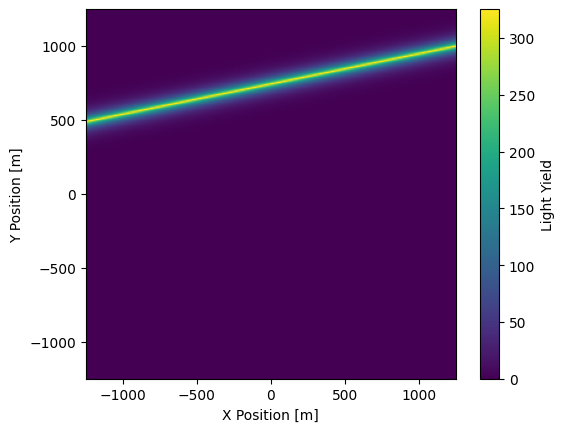

In [56]:
new_signal_events = signal_sampler.sample_events(1)  # Fresh signal events for optimization
new_background_events = background_sampler.sample_events(1)  # Fresh background events
domain_size = 2500
half_size = domain_size / 2
steps = 300
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
ly = torch.zeros((points.shape[0],))
for event_params in new_signal_events:
    # event_params['energy'] = torch.tensor([1e6])
    event_params['zenith'] = torch.tensor([torch.pi / 2])
    ly += light_yield_surrogate(opt_point=points, event_params=event_params).numpy()
ly = ly / len(new_signal_events)
ly_reshaped = ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_ly = np.sum(ly_reshaped, axis=2)
plt.imshow(avg_ly, extent=(-half_size, half_size, -half_size, half_size), cmap='viridis')
plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.colorbar(label='Light Yield')

In [5]:
test_num = 100
signal_yield_losses = np.zeros((test_num, test_num))
rov_penalty_losses = np.zeros((test_num, test_num))
local_repulsion_penalty_losses = np.zeros((test_num, test_num))
energy_resolution_losses = np.zeros((test_num, test_num))
angular_resolution_losses = np.zeros((test_num, test_num))
min_space = 20
max_space = 500
for i, z_spacing in enumerate(np.linspace(min_space, max_space, test_num)):  # Range of z_spacing values to test
    for j, string_spacing in enumerate(np.linspace(min_space, max_space, test_num)):  # Range of string_spacing values to test
        

        # geometry = nugget.geometries.EvanescentString.EvanescentString(
        geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=19,  # Initial number of detector strings
            points_per_string=5,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=string_spacing,
            starting_z_spacing=z_spacing
        )
        geom_dict = geometry.initialize_points()
        loss_params = {
        # 'llr_net': llr_net,
        'signal_event_params': new_signal_events,   
        'background_event_params': new_background_events,
        'signal_surrogate_func': light_yield_surrogate,  # Function to compute light yield
        'background_surrogate_func': light_yield_surrogate,
        'signal_sampler': signal_sampler,
        'background_sampler': background_sampler,
        'num_events': 50,  # Number of events to sample per optimization step
        'signal_noise_scale': 0.0,  # Noise level for signal events
        'background_noise_scale': 0.2,  # Noise level for background events
        'boundary_range': 2,  # Size of boundary region
        'eva_min_num_strings': 10,  # Minimum number of active strings
        'max_radius': 80,  # Maximum radius for string placement
        'num_angles': 10,  # Number of angles (divided into 360 degrees) to test for rov
        'local_sharpness': 10,  # Sharpness parameter for local string repulsion
        'string_number_beta':100,
        }
        # precomputed_fisher_info_per_string_per_event = angular_resolution_loss.compute_fisher_info_per_string_per_event(
        #         string_xy=geom_dict['string_xy'],
        #         points_3d=geom_dict['points_3d'],
        #         signal_event_params=new_signal_events,
        #         signal_surrogate_func=light_yield_surrogate,
        #     )
        # loss_params['precomputed_fisher_info_per_string_per_event'] = precomputed_fisher_info_per_string_per_event
        # signal_yield_losses[i, j] = signal_yield_loss_func(geom_dict, **loss_params)['signal_yield_loss'].item()
        rov_penalty_losses[i, j] = rov_penalty(geom_dict, **loss_params)['rov_penalty'].item()
        local_repulsion_penalty_losses[i, j] = local_repulsion_penalty(geom_dict, **loss_params)['local_repulsion_penalty'].item()
        # energy_resolution_losses[i,j] = energy_resolution_loss(geom_dict, **loss_params)['energy_resolution_loss'].item()
        # angular_resolution_losses[i, j] = angular_resolution_loss(geom_dict, **loss_params)['angular_resolution_loss'].item()*np.pi
        print(f"Completed ({i+1}, {j+1}) out of ({test_num}, {test_num})")
       

Completed (1, 1) out of (100, 100)
Completed (1, 2) out of (100, 100)
Completed (1, 3) out of (100, 100)
Completed (1, 4) out of (100, 100)
Completed (1, 5) out of (100, 100)
Completed (1, 6) out of (100, 100)
Completed (1, 7) out of (100, 100)
Completed (1, 8) out of (100, 100)
Completed (1, 9) out of (100, 100)
Completed (1, 10) out of (100, 100)
Completed (1, 11) out of (100, 100)
Completed (1, 12) out of (100, 100)
Completed (1, 13) out of (100, 100)
Completed (1, 14) out of (100, 100)
Completed (1, 15) out of (100, 100)
Completed (1, 16) out of (100, 100)
Completed (1, 17) out of (100, 100)
Completed (1, 18) out of (100, 100)
Completed (1, 19) out of (100, 100)
Completed (1, 20) out of (100, 100)
Completed (1, 21) out of (100, 100)
Completed (1, 22) out of (100, 100)
Completed (1, 23) out of (100, 100)
Completed (1, 24) out of (100, 100)
Completed (1, 25) out of (100, 100)
Completed (1, 26) out of (100, 100)
Completed (1, 27) out of (100, 100)
Completed (1, 28) out of (100, 100)
C

In [6]:
energy_resolution_losses = np.load('energy_resolution_losses_50_events_fixed_lightsabre.npy')
angular_resolution_losses = np.load('angular_resolution_losses_50_events_fixed_lightsabre.npy')
signal_yield_losses = np.load('signal_yield_losses_50_events_fixed_lightsabre.npy')
new_signal_events = pickle.load(open('loss_landscape_test_params_50_events_fixed_lightsabre.pkl', 'rb'))

In [11]:
energy_resolution_losses

array([[333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351],
       [333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351],
       [333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351],
       ...,
       [333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351],
       [333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351],
       [333.33334351, 333.33334351, 333.33334351, ..., 333.33334351,
        333.33334351, 333.33334351]], shape=(100, 100))

In [7]:
#create a list of 3d points in linspace within a domain of -2,2 in x,y,z, so that there is a 3d grid of points, which should be a list of shape (40x40x40,3)
steps = 200
domain_size = 2500
half_size = domain_size / 2
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
ly = torch.zeros((points.shape[0],))
for event_params in new_signal_events:
    ly += light_yield_surrogate(opt_point = points, event_params = event_params).numpy()
ly = ly / len(new_signal_events)


/tmp/ipykernel_899775/2497359302.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ly += light_yield_surrogate(opt_point = points, event_params = event_params).numpy()


/tmp/ipykernel_899775/1821235207.py:29: RuntimeWarning: divide by zero encountered in log10
  im3 = axes[1, 0].imshow(np.log10(local_repulsion_penalty_losses), extent=(min_space, max_space, max_space, min_space))


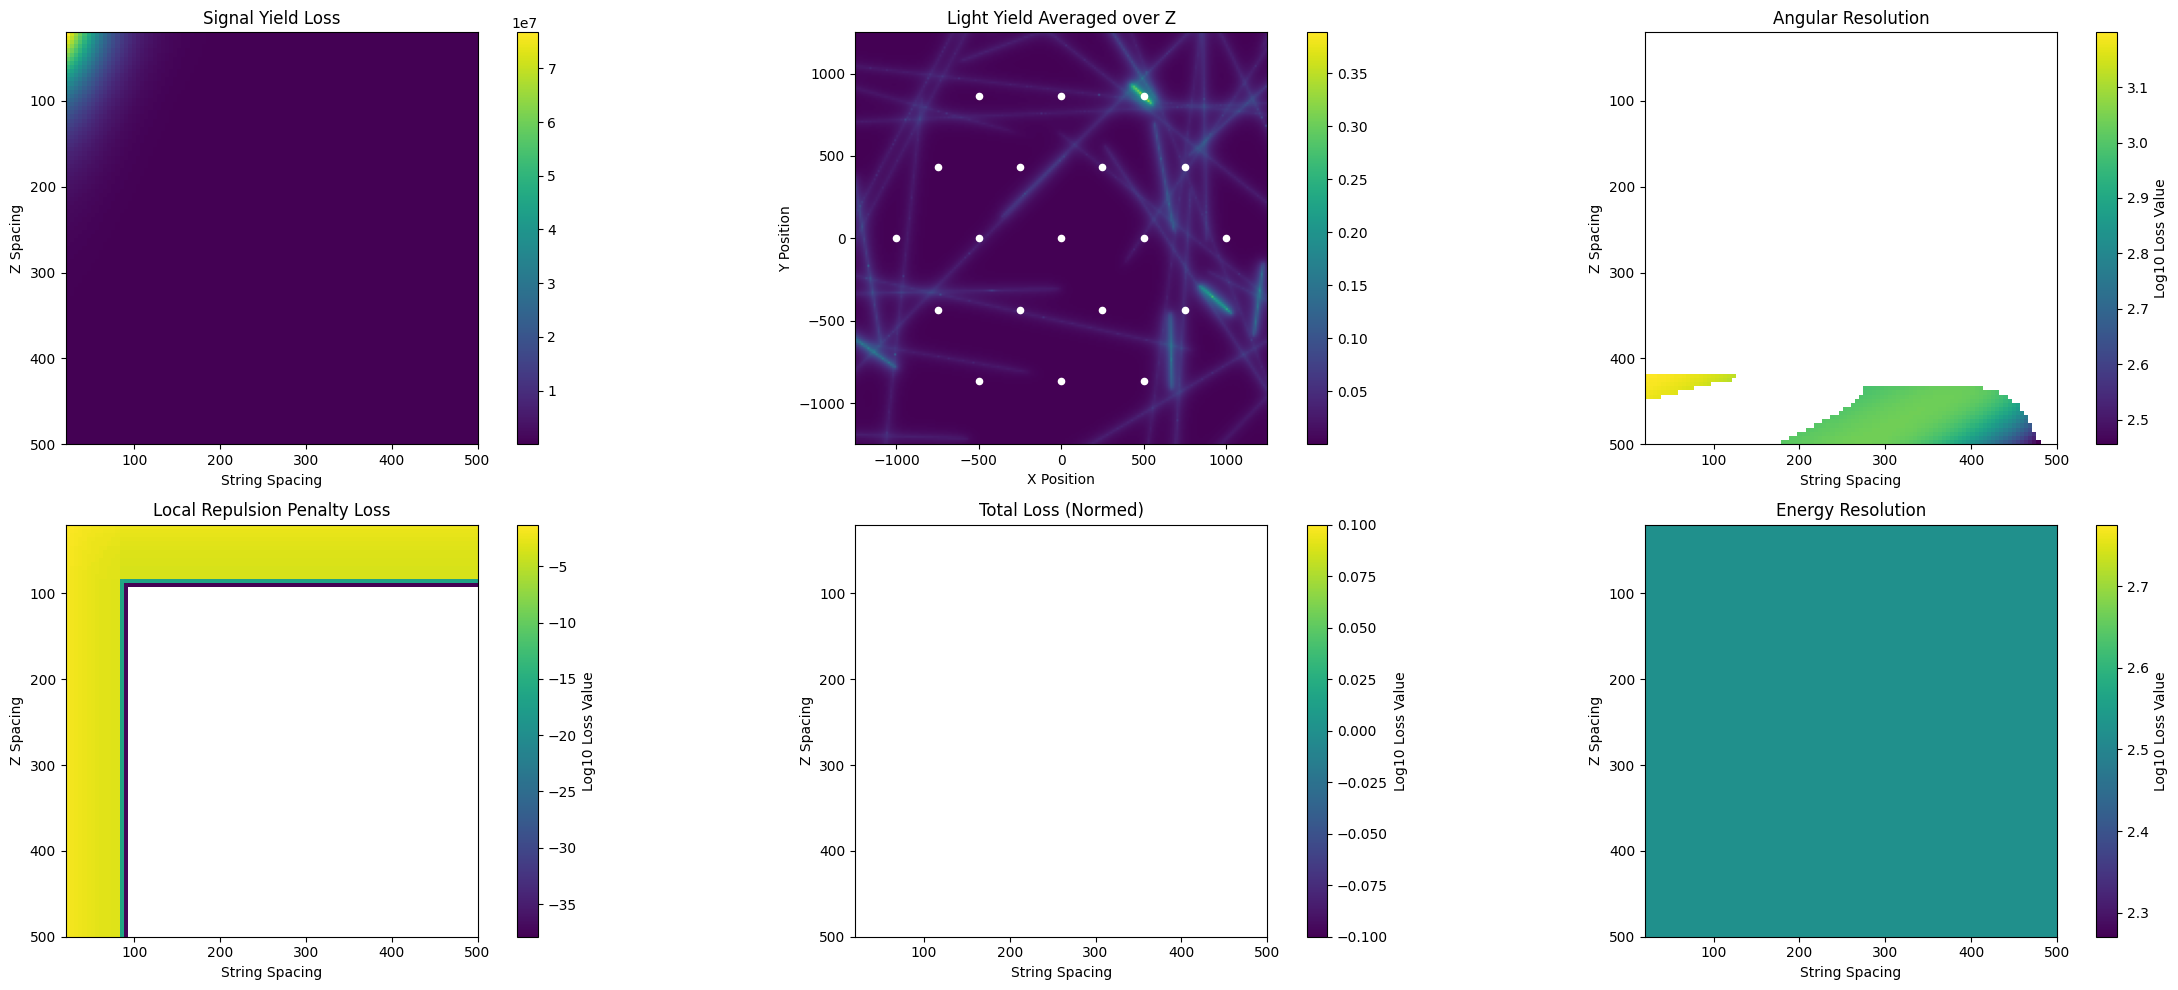

In [8]:
total_loss = signal_yield_losses/np.max(signal_yield_losses) + local_repulsion_penalty_losses/np.max(local_repulsion_penalty_losses) + angular_resolution_losses/np.max(angular_resolution_losses)  + energy_resolution_losses/np.max(energy_resolution_losses)
#all plots should be binned in logscale, use bins in logspace
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
im1 = axes[0, 0].imshow(signal_yield_losses, extent=(min_space, max_space, max_space, min_space))
axes[0, 0].set_title('Signal Yield Loss')
axes[0, 0].set_xlabel('String Spacing')
axes[0, 0].set_ylabel('Z Spacing')
fig.colorbar(im1, ax=axes[0, 0])
# axes[0, 0].set_xscale('log')
# axes[0, 0].set_yscale('log')
# im2 = axes[0, 1].imshow(np.log10(rov_penalty_losses/np.max(rov_penalty_losses)), extent=(0.02, 0.25, 0.25, 0.02))
# axes[0, 1].set_title('ROV Penalty Loss')
# axes[0, 1].set_xlabel('String Spacing')
# axes[0, 1].set_ylabel('Z Spacing')
# fig.colorbar(im2, ax=axes[0, 1])
# plot the average light yield across z for the 3d grid of points as a contour plot
# first reshape ly to a 40x40x40 array
ly_reshaped = ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_ly = np.mean(ly_reshaped, axis=2)
im2 = axes[0, 1].imshow(avg_ly, extent=(-half_size, half_size, -half_size, half_size), cmap='viridis')
# plot here also the xy points from geom_dict
axes[0, 1].scatter(geom_dict['string_xy'][:, 0], geom_dict['string_xy'][:, 1], c='white', s=20)
axes[0, 1].set_title('Light Yield Averaged over Z')
axes[0, 1].set_xlabel('X Position')
axes[0, 1].set_ylabel('Y Position')
fig.colorbar(im2, ax=axes[0, 1])

im3 = axes[1, 0].imshow(np.log10(local_repulsion_penalty_losses), extent=(min_space, max_space, max_space, min_space))
axes[1, 0].set_title('Local Repulsion Penalty Loss')
axes[1, 0].set_xlabel('String Spacing')
axes[1, 0].set_ylabel('Z Spacing')
fig.colorbar(im3, ax=axes[1, 0])
# axes[1, 0].set_xscale('log')
# axes[1, 0].set_yscale('log')
im4 = axes[1, 1].imshow(np.log10(total_loss), extent=(min_space, max_space, max_space, min_space))
axes[1, 1].set_title('Total Loss (Normed)')
axes[1, 1].set_xlabel('String Spacing')
axes[1, 1].set_ylabel('Z Spacing')
fig.colorbar(im4, ax=axes[1, 1])
im5 = axes[1, 2].imshow(np.log10(energy_resolution_losses), extent=(min_space, max_space, max_space, min_space))
axes[1, 2].set_title('Energy Resolution')
axes[1, 2].set_xlabel('String Spacing')
axes[1, 2].set_ylabel('Z Spacing')
fig.colorbar(im5, ax=axes[1, 2])
# axes[1, 2].set_xscale('log')
# axes[1, 2].set_yscale('log')
im6 = axes[0, 2].imshow(np.log10(angular_resolution_losses), extent=(min_space, max_space, max_space, min_space))
axes[0, 2].set_title('Angular Resolution')
axes[0, 2].set_xlabel('String Spacing')
axes[0, 2].set_ylabel('Z Spacing')
fig.colorbar(im6, ax=axes[0, 2])
#label the colorbars with 'Log10 Loss Value'
# im1.colorbar.set_label('Log10 Loss Value')
# im2.colorbar.set_label('Log10 Loss Value')
im3.colorbar.set_label('Log10 Loss Value')
im4.colorbar.set_label('Log10 Loss Value')
im5.colorbar.set_label('Log10 Loss Value')
im6.colorbar.set_label('Log10 Loss Value')

# axes[0, 2].set_xscale('log')
# axes[0, 2].set_yscale('log')
# axes[1, 2].remove()

plt.tight_layout()
plt.show()